In [108]:
from transformers import pipeline
from PIL import Image
from pathlib import Path
import pytesseract
import import_ipynb
import json
import os
import glob
import pdfplumber

In [109]:
from TEDS_calculation import teds

In [110]:
MARGIN_H = 20
MARGIN_V = 10

In [111]:
detect = pipeline("object-detection", model="microsoft/table-transformer-detection")

Some weights of the model checkpoint at microsoft/table-transformer-detection were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


In [112]:
def extract(path):
    custom_oem_psm_config = r'--oem 3 --psm 6'
    
    df = pytesseract.image_to_data(Image.open(path),
                                   output_type=pytesseract.Output.DATAFRAME,
                                   config=custom_oem_psm_config
                                   )
    df = df[df.conf > 30].dropna(subset=["text"])

    rows=[]
    for _, line in df.groupby(["line_num"]):
        row = []
        tmp = ""
        for i, (_,x) in enumerate(line.sort_values("left").iterrows()):
            if 0 == 1:
                tmp = x["text"]
                continue

            prev = line.iloc[i-1]
            # if the space between this word and the prev < 20, then they're both in the same cell
            # else, 
            gap = x["left"] - (prev["left"] + prev["width"])

            if gap < 20:
                tmp += " " + x["text"]
            else:
                row.append(tmp)
                tmp = x["text"]

        if tmp:
            row.append(tmp)

        rows.append(row)

    return {"headers": rows[0] if rows else [], "rows": rows[1:]}

In [113]:
with open(Path.cwd() / "model_output" / "qwen3_trained_json" / "02291274.json", "r") as f:
    raw = json.load(f)

print(json.loads(raw['/content/eval_set_images/02291274/page_002.png'])["tables"][0])

{'table_name': 'Micro-entity Balance Sheet as at 31 March 2025', 'headers': ['Notes', '2025 £', '2024 £'], 'rows': [['Called up share capital not paid', '5', '5'], ['Current Assets', '23,729', '16,551'], ['Net current assets (liabilities)', '23,729', '16,551'], ['Total assets less current liabilities', '23,734', '16,556'], ['Total net assets (liabilities)', '23,734', '16,556'], ['Capital and reserves', '23,734', '16,556']]}


In [114]:
def extract_table_n_tesseract(img_path):
    com_num = Path(img_path).parts[-2]
    page_num = Path(img_path).stem

    save_dir = Path().cwd() / "tesseract_out" / com_num / page_num
    
    Path.mkdir(save_dir, parents=True, exist_ok=True)

    img = Image.open(img_path).convert("RGB")
    for i, d in enumerate(detect(img)):
        save_path = save_dir / f"table_{i+1:02d}.png"

        print(f"{com_num}/{page_num} Score: {d["score"]}")
        if d["score"] > 0.85:
            b = d["box"]
            img.crop((b["xmin"] - MARGIN_H, b["ymin"] - MARGIN_V, b["xmax"] + MARGIN_H, b["ymax"] + MARGIN_V)).save(save_path)

            extract(Path.cwd() / "table_0.png")

In [115]:
com_list = [Path(x).stem for x in glob.glob(str(Path.cwd() / "eval_set_images" / "*"))]

In [116]:
for com in com_list:
    aa_pages_path = glob.glob(str(Path.cwd() / "eval_set_images" / com / "*.png"))
    for page_path in aa_pages_path:
        extract_table_n_tesseract(page_path)

02291274/page_001 Score: 0.599617063999176
02291274/page_001 Score: 0.5905196070671082
02291274/page_001 Score: 0.8088032603263855
02291274/page_002 Score: 0.9930397272109985


FileNotFoundError: [Errno 2] No such file or directory: 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\table_0.png'

In [ ]:
for com in com_list:
    aa_pages_path = glob.glob(str(Path.cwd() / "eval_set_pdf" / "*.pdf"))
    print(aa_pages_path)
    for page_path in aa_pages_path:
        with pdfplumber.open(page_path) as pdf:
            tables = pdf.pages[0].extract_tables()


print(tables)

['d:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\02291274.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\02526128.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\02859692.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\03004352.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\04774581.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\06617562.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\10192734.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\13700075.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\13879337.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\14361496.pdf', 'd:\\University\\Masters\\Project\\team_21_lloyds\\Evaluation\\eval_set_pdf\\15

In [ ]:
tesseract_teds = {}
for com in com_list:
    grnd_path = Path.cwd().parent / "DataPreprocess" / "annotations" / f"{com}.json"

    with open(grnd_path, "r") as f:
        grnd_table = json.load(f)

    # for all pages
    for page in grnd_table.keys():
        grnd_truth = grnd_table[page]

        # if no tables are found in tess AND grnd, TEDS 1 else: tess has no tables but grnd does TEDS 0  
        if len(glob.glob(str(Path.cwd() / "tesseract_out" / com / f"{page.split(".")[0]}" / "*.png"))) == 0:
            if grnd_truth["payload"]["table_found"] == False:
                tesseract_teds[f"{com}/{page.split(".")[0]}"] = 1
                continue
            else: 
                tesseract_teds[f"{com}/{page.split(".")[0]}"] = 0
                continue

        # if table found in tess BUT NOT grnd, TEDS 0
        if len(glob.glob(str(Path.cwd() / "tesseract_out" / com / f"{page.split(".")[0]}" / "*.png"))) and not grnd_truth["payload"]["table_found"]:
            tesseract_teds[f"{com}/{page.split(".")[0]}"] = 0
            continue

        # find avg of TEDS in each page
        tess_table_paths = glob.glob(str(Path.cwd() / "tesseract_out" / com / f"{page.split(".")[0]}" / "*.png"))
        tess_tables = [extract(tess_table) for tess_table in tess_table_paths]

        table_score = []
        print(grnd_truth["payload"])
        for i in range(min(len(grnd_truth["payload"]["tables"]), len(tess_tables))):
            table_score.append(teds(grnd_truth["payload"]["tables"][i], tess_tables[i]))


        tesseract_teds[f"{com}/{page.split(".")[0]}"] = sum(table_score)/len(table_score)

{'table_found': True, 'tables': [{'table_name': 'Micro-entity Balance Sheet as at 31 March 2025', 'headers': ['Item', 'Notes', '2025 ยฃ', '2024 ยฃ'], 'rows': [['Called up share capital not paid', None, '5', '5'], ['Current Assets', None, '23,729', '16,551'], ['Net current assets (liabilities)', None, '23,729', '16,551'], ['Total assets less current liabilities', None, '23,734', '16,556'], ['Total net assets (liabilities)', None, '23,734', '16,556'], ['Capital and reserves', None, '23,734', '16,556']]}]}
{'table_found': True, 'tables': [{'table_name': 'Balance Sheet', 'headers': ['Item', '2025 ยฃ', '2024 ยฃ'], 'rows': [['Current assets', '1,472', '2,131'], ['Creditors: Amounts Falling Due Within One Year', '(120)', '(816)'], ['NET CURRENT ASSETS', '1,352', '1,315'], ['TOTAL ASSETS LESS CURRENT LIABILITIES', '1,352', '1,315'], ['NET ASSETS', '1,352', '1,315'], ['CAPITAL AND RESERVES', '1,352', '1,315']]}]}
{'table_found': True, 'tables': [{'table_name': 'Current Assets and Liabilities', 

In [ ]:
untrained_qwen_teds = {}
for com in com_list:
    if com == "14361496":
        continue
    grnd_path = Path.cwd().parent / "DataPreprocess" / "annotations" / f"{com}.json"
    untrained_qwen_path = Path.cwd() / "model_output" / "qwen3_untrained_json" / f"{com}.json"

    with open(grnd_path, "r") as f:
        grnd_table = json.load(f)

    with open(untrained_qwen_path, "r") as f:
        untrained_qwen_table = json.load(f)

    print(untrained_qwen_table)
    # for all pages
    for page in grnd_table.keys():
        grnd_truth = grnd_table[page]
        comparison_table = untrained_qwen_table[f"/content/eval_set_images/{com}/{page}"]

        comparison_table = json.loads(comparison_table)
        if grnd_truth["payload"]["table_found"] == False:
            if comparison_table["table_found"] == False:
                untrained_qwen_teds[f"{com}/{page.split(".")[0]}"] = 1
                continue
            else:
                untrained_qwen_teds[f"{com}/{page.split(".")[0]}"] = 0
                continue

        if comparison_table["table_found"] == False and grnd_truth["payload"]["table_found"] == True:
            untrained_qwen_teds[f"{com}/{page.split(".")[0]}"] = 0
            continue

        table_score = []
        for i in range(min(len(grnd_truth["payload"]["tables"]), len(comparison_table["tables"]))):
            table_score.append(teds(grnd_truth["payload"]["tables"][i], comparison_table["tables"][i]))

        untrained_qwen_teds[f"{com}/{page.split(".")[0]}"] = sum(table_score)/len(table_score)

{'/content/eval_set_images/02291274/page_001.png': '{"table_found": false}', '/content/eval_set_images/02291274/page_002.png': '{\n  "table_found": true,\n  "tables": [\n    {\n      "table_name": "Micro-entity Balance Sheet as at 31 March 2025",\n      "headers": [\n        "Notes",\n        "2025",\n        "2024"\n      ],\n      "rows": [\n        [\n          "Called up share capital not paid",\n          "5",\n          "5"\n        ],\n        [\n          "Current Assets",\n          "23,729",\n          "16,551"\n        ],\n        [\n          "Net current assets (liabilities)",\n          "23,729",\n          "16,551"\n        ],\n        [\n          "Total assets less current liabilities",\n          "23,734",\n          "16,556"\n        ],\n        [\n          "Total net assets (liabilities)",\n          "23,734",\n          "16,556"\n        ],\n        [\n          "Capital and reserves",\n          "23,734",\n          "16,556"\n        ]\n      ]\n    }\n  ]\n}', '

In [ ]:
trained_qwen_teds = {}
for com in com_list:
    if com == "14361496":
        continue
    grnd_path = Path.cwd().parent / "DataPreprocess" / "annotations" / f"{com}.json"
    trained_qwen_path = Path.cwd() / "model_output" / "qwen3_trained_json" / f"{com}.json"

    with open(grnd_path, "r") as f:
        grnd_table = json.load(f)

    with open(trained_qwen_path, "r") as f:
        trained_qwen_table = json.load(f)

    print(trained_qwen_table)
    # for all pages
    for page in grnd_table.keys():
        grnd_truth = grnd_table[page]
        comparison_table = trained_qwen_table[f"/content/eval_set_images/{com}/{page}"]

        comparison_table = json.loads(comparison_table)
        if grnd_truth["payload"]["table_found"] == False:
            if comparison_table["table_found"] == False:
                trained_qwen_teds[f"{com}/{page.split(".")[0]}"] = 1
                continue
            else:
                trained_qwen_teds[f"{com}/{page.split(".")[0]}"] = 0
                continue

        if comparison_table["table_found"] == False and grnd_truth["payload"]["table_found"] == True:
            trained_qwen_teds[f"{com}/{page.split(".")[0]}"] = 0
            continue

        table_score = []
        for i in range(min(len(grnd_truth["payload"]["tables"]), len(comparison_table["tables"]))):
            table_score.append(teds(grnd_truth["payload"]["tables"][i], comparison_table["tables"][i]))

        trained_qwen_teds[f"{com}/{page.split(".")[0]}"] = sum(table_score)/len(table_score)

{'/content/eval_set_images/02291274/page_001.png': '{"table_found": false}', '/content/eval_set_images/02291274/page_002.png': '{"table_found": true, "tables": [{"table_name": "Micro-entity Balance Sheet as at 31 March 2025", "headers": ["Notes", "2025 £", "2024 £"], "rows": [["Called up share capital not paid", "5", "5"], ["Current Assets", "23,729", "16,551"], ["Net current assets (liabilities)", "23,729", "16,551"], ["Total assets less current liabilities", "23,734", "16,556"], ["Total net assets (liabilities)", "23,734", "16,556"], ["Capital and reserves", "23,734", "16,556"]]}]}', '/content/eval_set_images/02291274/page_003.png': '{"table_found": true, "tables": [{"table_name": "Average number of employees during the period", "headers": ["Item", "2025", "2024"], "rows": [["Average number of employees during the period", "5", "5"]]}]}'}
{'/content/eval_set_images/02526128/page_001.png': '{"table_found": false}', '/content/eval_set_images/02526128/page_002.png': '{"table_found": tru

In [ ]:
trained_qwen_teds

{'02291274/page_001': 1,
 '02291274/page_002': 0.7896825396825397,
 '02291274/page_003': 1.0,
 '02526128/page_002': 0.9113300492610837,
 '02526128/page_001': 1,
 '02526128/page_003': 1,
 '02859692/page_001': 1,
 '02859692/page_002': 0.9875776397515528,
 '02859692/page_003': 1.0,
 '03004352/page_004': 0.782312925170068,
 '03004352/page_006': 1,
 '03004352/page_005': 1,
 '04774581/page_001': 1,
 '04774581/page_002': 0.9875776397515528,
 '04774581/page_003': 1,
 '04774581/page_004': 1.0,
 '06617562/page_001': 1,
 '06617562/page_002': 0.9860627177700348,
 '06617562/page_003': 1.0,
 '10192734/page_001': 1,
 '10192734/page_002': 0.7485714285714286,
 '10192734/page_003': 1,
 '13700075/page_002': 0.5049833887043189,
 '13700075/page_003': 0,
 '13700075/page_007': 1,
 '13700075/page_008': 0.8669312169312169,
 '13700075/page_009': 0.4972260015117158,
 '13700075/page_010': 0,
 '13700075/page_011': 1,
 '13879337/page_001': 1,
 '13879337/page_002': 0.9826839826839827,
 '13879337/page_003': 1,
 '1522

In [ ]:
from matplotlib.pyplot import subplots 

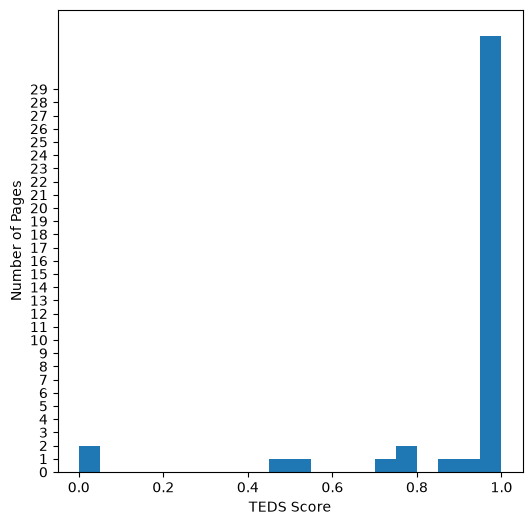

In [138]:
fig, ax = subplots(figsize=(6,6))
ax.hist(trained_qwen_teds.values(),bins = 20)
ax.set_ylim(0,35)
ax.set_yticks(range(0,30))
ax.set_xlabel("TEDS Score")
ax.set_ylabel("Number of Pages")
fig.savefig("trained_qwen_teds_histogram.png")

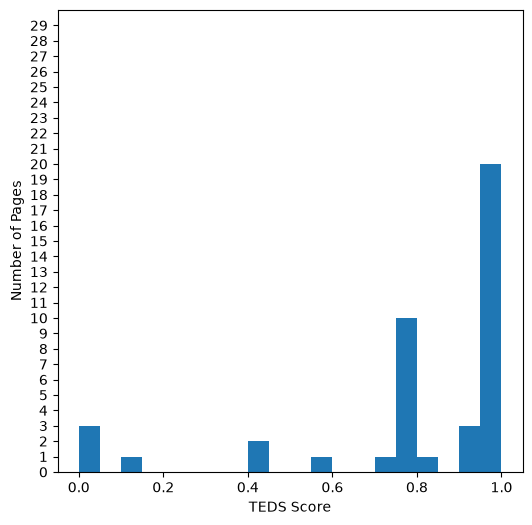

In [140]:
fig, ax = subplots(figsize=(6,6))
ax.hist(untrained_qwen_teds.values(),bins = 20)
ax.set_ylim(0,30)
ax.set_yticks(range(0,30))
ax.set_xlabel("TEDS Score")
ax.set_ylabel("Number of Pages")
fig.savefig("untrained_qwen_teds_histogram.png")

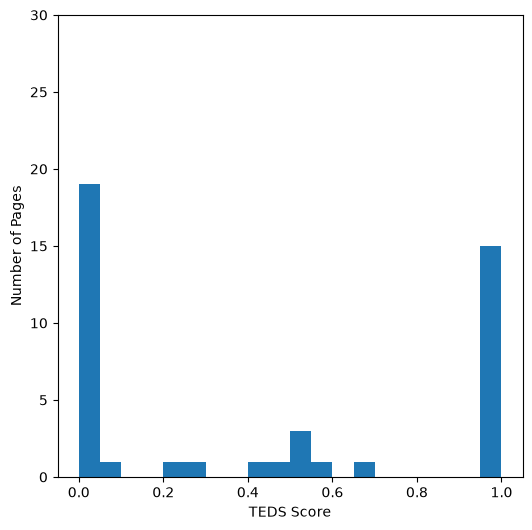

In [135]:
ax = subplots(figsize=(6,6))[1]
ax.hist(tesseract_teds.values(),bins = 20)
ax.set_ylim(0,30)
ax.set_xlabel("TEDS Score")
ax.set_ylabel("Number of Pages")
fig.savefig("tesseract_teds_histogram.png")

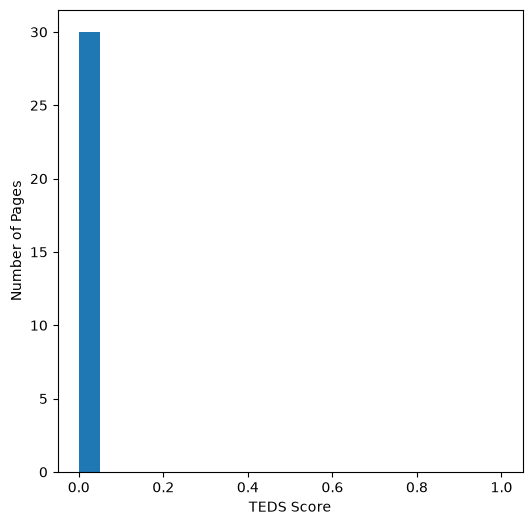

In [120]:
ax = subplots(figsize=(6,6))[1]
ax.hist([0 for i in range(30)],bins = 20, range = [0,1])
ax.set_xlabel("TEDS Score")
ax.set_ylabel("Number of Pages")
fig.savefig("pdfplumber_teds_histogram.png")

In [121]:
pre_trained_avg = sum(untrained_qwen_teds.values()) / len(untrained_qwen_teds.values())
post_trained_avg = sum(trained_qwen_teds.values()) / len(trained_qwen_teds.values())

In [122]:
pre_trained_avg

0.8037466065408885

In [123]:
post_trained_avg

0.9040235226800661

In [124]:
trained_qwen_teds

{'02291274/page_001': 1,
 '02291274/page_002': 0.7896825396825397,
 '02291274/page_003': 1.0,
 '02526128/page_002': 0.9113300492610837,
 '02526128/page_001': 1,
 '02526128/page_003': 1,
 '02859692/page_001': 1,
 '02859692/page_002': 0.9875776397515528,
 '02859692/page_003': 1.0,
 '03004352/page_004': 0.782312925170068,
 '03004352/page_006': 1,
 '03004352/page_005': 1,
 '04774581/page_001': 1,
 '04774581/page_002': 0.9875776397515528,
 '04774581/page_003': 1,
 '04774581/page_004': 1.0,
 '06617562/page_001': 1,
 '06617562/page_002': 0.9860627177700348,
 '06617562/page_003': 1.0,
 '10192734/page_001': 1,
 '10192734/page_002': 0.7485714285714286,
 '10192734/page_003': 1,
 '13700075/page_002': 0.5049833887043189,
 '13700075/page_003': 0,
 '13700075/page_007': 1,
 '13700075/page_008': 0.8669312169312169,
 '13700075/page_009': 0.4972260015117158,
 '13700075/page_010': 0,
 '13700075/page_011': 1,
 '13879337/page_001': 1,
 '13879337/page_002': 0.9826839826839827,
 '13879337/page_003': 1,
 '1522